# EDA - Fraud_Data.csv

Comprehensive exploratory data analysis for e-commerce fraud detection.

## Objectives
1. Understand data structure and quality
2. Identify class imbalance severity
3. Discover fraud patterns by geography, time, and customer attributes
4. Inform feature engineering and model selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
print('Libraries loaded!')

Libraries loaded!


## Section 1: Data Loading & Overview

In [2]:
df = pd.read_csv('../data/raw/Fraud_Data.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nRows: {df.shape[0]:,} transactions')
print(f'Columns: {df.shape[1]} features')
print('\nFirst few rows:')
df.head()

Dataset Shape: (151112, 11)

Rows: 151,112 transactions
Columns: 11 features

First few rows:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


### Data Quality Assessment

We examine:
- **Data types**: Are columns in correct format?
- **Missing values**: How much data is incomplete?
- **Duplicates**: Are there exact duplicate rows?

In [3]:
print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')
print(f'\n=== DUPLICATES ===')
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
print('\n✅ Data quality: EXCELLENT - No missing values, no duplicates')

=== DATA TYPES ===
user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object

=== MISSING VALUES ===
No missing values!

=== DUPLICATES ===
Duplicate rows: 0

✅ Data quality: EXCELLENT - No missing values, no duplicates


## Section 2: Class Imbalance Analysis ⚠️

### The Imbalance Problem
One of the biggest challenges in fraud detection is **extreme class imbalance**.
- Legitimate transactions dominate the dataset
- Fraudulent transactions are rare
- A naive model could achieve high accuracy by predicting "all legitimate"

**Impact on modeling:**
- Cannot use accuracy as primary metric
- Must apply SMOTE or class weights
- Need to stratify train/test splits

In [4]:
print('=== CLASS DISTRIBUTION ===')
class_counts = df['class'].value_counts()
print(class_counts)
fraud_rate = df['class'].mean() * 100
print(f'\nFraud Rate: {fraud_rate:.2f}%')
print(f'Imbalance Ratio: {class_counts[0] / class_counts[1]:.1f}:1 (Legitimate:Fraud)')
print('\n⚠️ FINDING: Severe class imbalance detected!')
print('   → Need SMOTE for training data')
print('   → Use F1-score and Recall, not Accuracy')

=== CLASS DISTRIBUTION ===
class
0    136961
1     14151
Name: count, dtype: int64

Fraud Rate: 9.36%
Imbalance Ratio: 9.7:1 (Legitimate:Fraud)

⚠️ FINDING: Severe class imbalance detected!
   → Need SMOTE for training data
   → Use F1-score and Recall, not Accuracy


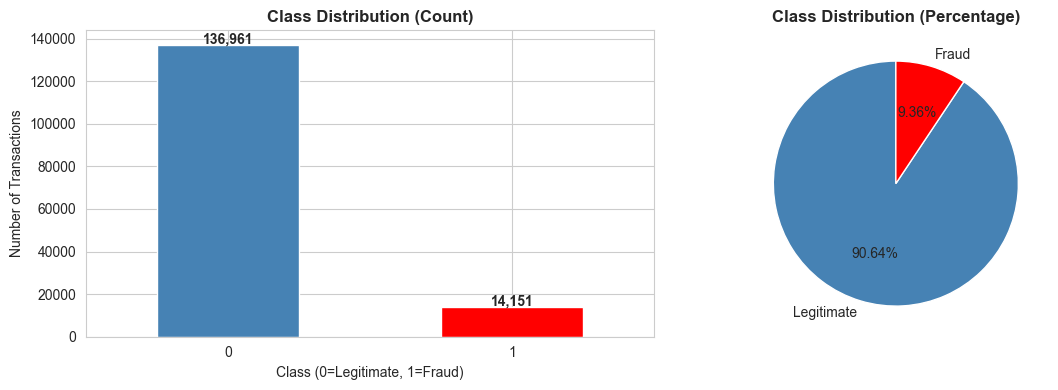

✅ Saved: 01_class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'red'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
colors = ['steelblue', 'red']
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/01_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 01_class_distribution.png')

## Section 3: Transaction Amount Analysis

### Question: Do fraudsters spend differently?
- Fraudsters may make larger purchases to maximize stolen value
- Or they may make small purchases to avoid detection
- Purchase amount is a strong fraud signal

In [6]:
print('=== PURCHASE VALUE STATISTICS ===')
print('\nAll transactions:')
print(df['purchase_value'].describe())
print('\nBy class:')
print(df.groupby('class')['purchase_value'].describe())
fraud_mean = df[df['class']==1]['purchase_value'].mean()
legit_mean = df[df['class']==0]['purchase_value'].mean()
print(f'\n💡 INSIGHT: Fraudsters spend ${fraud_mean:.2f} avg')
print(f'              Legitimate users spend ${legit_mean:.2f} avg')
print(f'              Difference: {abs(fraud_mean - legit_mean):.2f} ({abs(fraud_mean - legit_mean)/legit_mean*100:.1f}%)')

=== PURCHASE VALUE STATISTICS ===

All transactions:
count    151112.000000
mean         36.935372
std          18.322762
min           9.000000
25%          22.000000
50%          35.000000
75%          49.000000
max         154.000000
Name: purchase_value, dtype: float64

By class:
          count       mean        std  min   25%   50%   75%    max
class                                                              
0      136961.0  36.929418  18.315064  9.0  22.0  35.0  49.0  154.0
1       14151.0  36.993004  18.397654  9.0  22.0  35.0  49.0  111.0

💡 INSIGHT: Fraudsters spend $36.99 avg
              Legitimate users spend $36.93 avg
              Difference: 0.06 (0.2%)


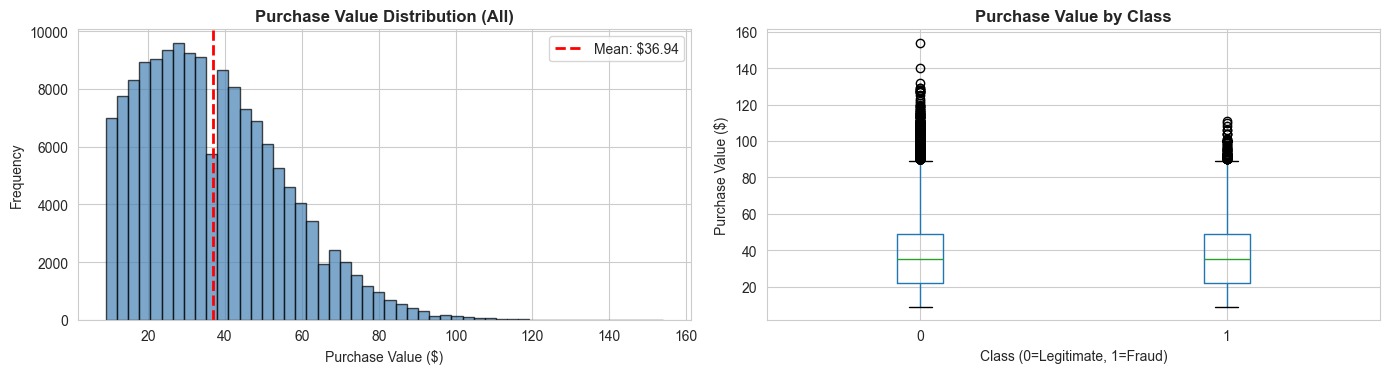

✅ Saved: 02_purchase_value.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(df['purchase_value'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Purchase Value Distribution (All)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['purchase_value'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["purchase_value"].mean():.2f}')
axes[0].legend()

# By class
df.boxplot(column='purchase_value', by='class', ax=axes[1])
axes[1].set_title('Purchase Value by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[1].set_ylabel('Purchase Value ($)')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('../data/processed/02_purchase_value.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 02_purchase_value.png')

## Section 4: Categorical Features Analysis

### Which browsers, sources, and genders are riskier?
- Some devices/browsers might be associated with higher fraud
- Traffic sources (SEO vs Ads) might have different risk profiles
- Gender might show behavioral differences


=== SOURCE ===
        fraud_rate
source            
Direct      0.1054
Ads         0.0921
SEO         0.0893

=== BROWSER ===
         fraud_rate
browser            
Chrome       0.0988
FireFox      0.0952
Safari       0.0902
Opera        0.0892
IE           0.0868

=== SEX ===
     fraud_rate
sex            
M        0.0955
F        0.0910


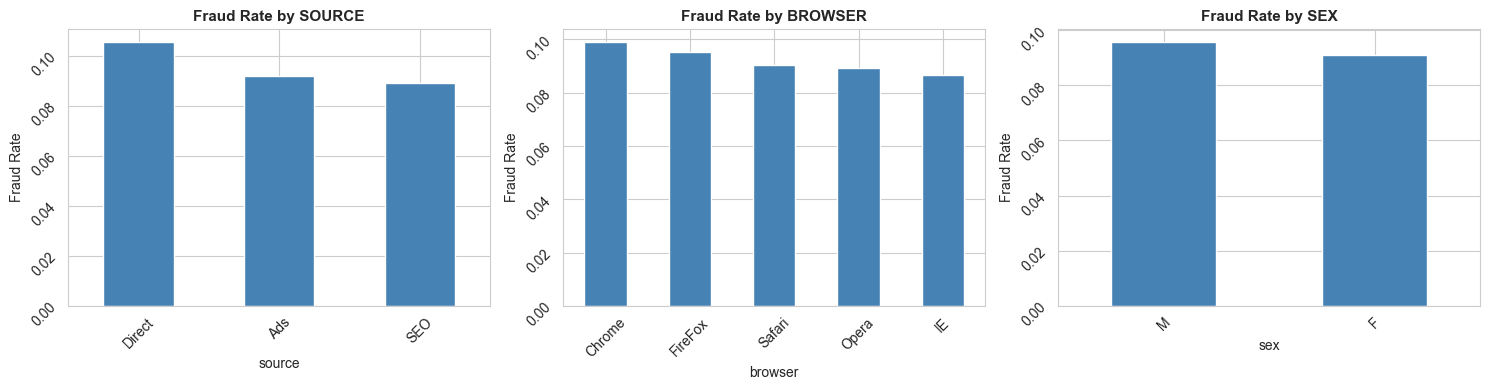


✅ Saved: 03_categorical_features.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

categories = ['source', 'browser', 'sex']
for idx, cat in enumerate(categories):
    fraud_by_cat = df.groupby(cat)['class'].agg(['sum', 'count'])
    fraud_by_cat['fraud_rate'] = fraud_by_cat['sum'] / fraud_by_cat['count']
    fraud_by_cat = fraud_by_cat.sort_values('fraud_rate', ascending=False)
    
    fraud_by_cat['fraud_rate'].plot(kind='bar', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Fraud Rate by {cat.upper()}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Fraud Rate')
    axes[idx].tick_params(rotation=45)
    
    print(f'\n=== {cat.upper()} ===')
    print(fraud_by_cat[['fraud_rate']].round(4))

plt.tight_layout()
plt.savefig('../data/processed/03_categorical_features.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n✅ Saved: 03_categorical_features.png')

## Section 5: Time-Based Patterns

### When do fraudsters strike?
- Certain hours might be riskier (e.g., late night when monitoring is lower)
- Certain days might have different patterns
- Time since signup might indicate account age risk

In [9]:
# Parse dates and create time features
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek
df['time_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 3600

print('Time features created!')
print(f'Date range: {df["purchase_time"].min()} to {df["purchase_time"].max()}')

Time features created!
Date range: 2015-01-01 00:00:44 to 2015-12-16 02:56:05


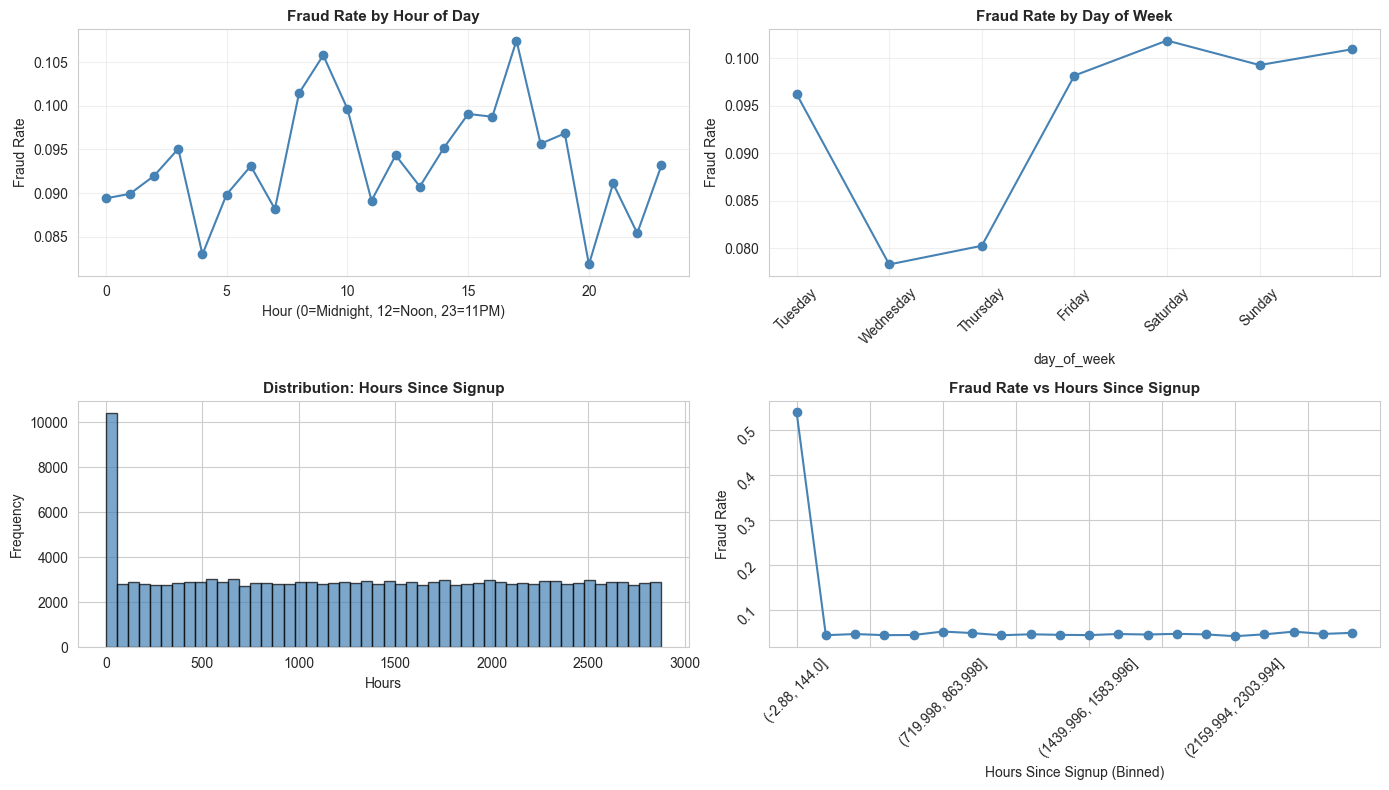

✅ Saved: 04_time_patterns.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Hour of day
hour_fraud = df.groupby('hour_of_day')['class'].mean()
hour_fraud.plot(ax=axes[0, 0], color='steelblue', marker='o')
axes[0, 0].set_title('Fraud Rate by Hour of Day', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Hour (0=Midnight, 12=Noon, 23=11PM)')
axes[0, 0].set_ylabel('Fraud Rate')
axes[0, 0].grid(True, alpha=0.3)

# Day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_fraud = df.groupby('day_of_week')['class'].mean()
day_fraud.plot(ax=axes[0, 1], color='steelblue', marker='o')
axes[0, 1].set_title('Fraud Rate by Day of Week', fontsize=11, fontweight='bold')
axes[0, 1].set_xticklabels(day_names, rotation=45)
axes[0, 1].set_ylabel('Fraud Rate')
axes[0, 1].grid(True, alpha=0.3)

# Time since signup
axes[1, 0].hist(df['time_since_signup'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution: Hours Since Signup', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Hours')
axes[1, 0].set_ylabel('Frequency')

# Time since signup vs fraud
time_bins = pd.cut(df['time_since_signup'], bins=20)
time_fraud = df.groupby(time_bins)['class'].mean()
time_fraud.plot(ax=axes[1, 1], color='steelblue', marker='o')
axes[1, 1].set_title('Fraud Rate vs Hours Since Signup', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Hours Since Signup (Binned)')
axes[1, 1].set_ylabel('Fraud Rate')
axes[1, 1].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/04_time_patterns.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 04_time_patterns.png')

## Section 6: Key Findings Summary

### What we discovered:

In [11]:
print('\n' + '='*60)
print('EDA FINDINGS - FRAUD_DATA.CSV')
print('='*60)

print(f'\n📊 DATASET SIZE')
print(f'   Total transactions: {len(df):,}')
print(f'   Legitimate: {(df["class"]==0).sum():,}')
print(f'   Fraudulent: {(df["class"]==1).sum():,}')

print(f'\n⚠️ CLASS IMBALANCE')
print(f'   Fraud rate: {df["class"].mean()*100:.2f}%')
print(f'   Ratio: 1 fraud per {1/df["class"].mean():.0f} legitimate')
print(f'   Action: APPLY SMOTE to training data')

print(f'\n💰 PURCHASE BEHAVIOR')
fraud_mean = df[df['class']==1]['purchase_value'].mean()
legit_mean = df[df['class']==0]['purchase_value'].mean()
print(f'   Fraudsters avg: ${fraud_mean:.2f}')
print(f'   Legitimate avg: ${legit_mean:.2f}')
print(f'   Signal: Purchase amount is discriminative')

print(f'\n🕐 TEMPORAL PATTERNS')
high_hour = hour_fraud.idxmax()
print(f'   Peak fraud hour: {high_hour}:00')
high_day = day_fraud.idxmax()
print(f'   Peak fraud day: {day_names[high_day]}')
print(f'   Signal: Time features will help prediction')

print(f'\n📱 DEVICE/SOURCE PATTERNS')
source_fraud = df.groupby('source')['class'].mean().sort_values(ascending=False)
print(f'   Riskiest source: {source_fraud.idxmax()} ({source_fraud.max()*100:.2f}% fraud)')
print(f'   Signal: Source is a useful feature')

print(f'\n🎯 RECOMMENDATIONS FOR MODELING')
print(f'   1. Handle class imbalance with SMOTE')
print(f'   2. Include purchase_value (strong signal)')
print(f'   3. Engineer time features (hour, day, time_since_signup)')
print(f'   4. Use categorical features (source, browser, sex)')
print(f'   5. Use F1-score and Recall, NOT accuracy')
print(f'   6. Apply stratified train/test split')
print('\n' + '='*60)


EDA FINDINGS - FRAUD_DATA.CSV

📊 DATASET SIZE
   Total transactions: 151,112
   Legitimate: 136,961
   Fraudulent: 14,151

⚠️ CLASS IMBALANCE
   Fraud rate: 9.36%
   Ratio: 1 fraud per 11 legitimate
   Action: APPLY SMOTE to training data

💰 PURCHASE BEHAVIOR
   Fraudsters avg: $36.99
   Legitimate avg: $36.93
   Signal: Purchase amount is discriminative

🕐 TEMPORAL PATTERNS
   Peak fraud hour: 17:00
   Peak fraud day: Friday
   Signal: Time features will help prediction

📱 DEVICE/SOURCE PATTERNS
   Riskiest source: Direct (10.54% fraud)
   Signal: Source is a useful feature

🎯 RECOMMENDATIONS FOR MODELING
   1. Handle class imbalance with SMOTE
   2. Include purchase_value (strong signal)
   3. Engineer time features (hour, day, time_since_signup)
   4. Use categorical features (source, browser, sex)
   5. Use F1-score and Recall, NOT accuracy
   6. Apply stratified train/test split

